✅ Dataset extraído en: /content/SecureNLP_SubTask1
/content/SecureNLP_SubTask1
/content/SecureNLP_SubTask1/dev
/content/SecureNLP_SubTask1/dev/annotations
/content/SecureNLP_SubTask1/dev/tokenized
/content/SecureNLP_SubTask1/train
/content/SecureNLP_SubTask1/train/plaintext
/content/SecureNLP_SubTask1/train/additional_plaintext
/content/SecureNLP_SubTask1/train/annotations
/content/SecureNLP_SubTask1/train/tokenized
/content/SecureNLP_SubTask1/test_1
/content/SecureNLP_SubTask1/test_1/annotations
/content/SecureNLP_SubTask1/test_1/tokenized
✅ train.csv generado con 9435 frases
✅ dev.csv generado con 1213 frases
✅ test_1.csv generado con 618 frases
TRAIN  → total=9435, relevantes=2204, irrelevantes=7231, ratio≈3.28:1
DEV    → total=1213, relevantes=79, irrelevantes=1134, ratio≈14.35:1
TEST_1 → total=618, relevantes=90, irrelevantes=528, ratio≈5.87:1


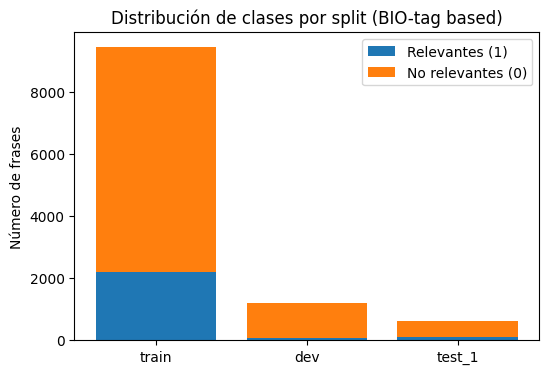


📁 CSVs guardados en: /content/output_csv_SubTask1


In [ ]:
# ============================================================
# ✅ Generación "oficial" estilo SemEval-2018 SubTask1 (usa test_1)
# ============================================================

import os
import csv
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1️⃣ RUTAS
# ------------------------------------------------------------
zip_path = "/content/SecureNLP_SubTask1.zip"   # ← sube aquí el .zip del dataset
extract_path = "/content/SecureNLP_SubTask1"
output_dir = "/content/output_csv_SubTask1"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 2️⃣ EXTRACCIÓN SEGURA
# ------------------------------------------------------------
def safe_extract(zip_file, path):
    for member in zip_file.namelist():
        fixed = member.replace("\\", "/")
        dest = os.path.join(path, fixed)
        if member.endswith("/"):
            os.makedirs(dest, exist_ok=True)
        else:
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            with zip_file.open(member) as src, open(dest, "wb") as out:
                out.write(src.read())

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        safe_extract(z, extract_path)
print("✅ Dataset extraído en:", extract_path)

# mostramos estructura base
!find $extract_path -maxdepth 3 -type d

# ------------------------------------------------------------
# 3️⃣ FUNCIÓN DE PROCESAMIENTO SIMPLE
# ------------------------------------------------------------
def process_tokenized_folder(folder_path, output_csv):
    tokenized_files = [f for f in os.listdir(folder_path) if f.endswith('.tokens')]
    rows = []

    for filename in tokenized_files:
        file_path = os.path.join(folder_path, filename)
        prefix = os.path.splitext(filename)[0]
        sentence_tokens, sentence_labels = [], []
        sentence_count = 1

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()
                if not line:
                    if sentence_tokens:
                        label = 0 if all(lab == "O" for lab in sentence_labels) else 1
                        text = " ".join(sentence_tokens)
                        row_id = f"{prefix}-{sentence_count}"
                        rows.append([row_id, text, label])
                        sentence_tokens, sentence_labels = [], []
                        sentence_count += 1
                    continue
                parts = line.split()
                token, tag = " ".join(parts[:-1]), parts[-1]
                sentence_tokens.append(token)
                sentence_labels.append(tag)

        if sentence_tokens:
            label = 0 if all(lab == "O" for lab in sentence_labels) else 1
            text = " ".join(sentence_tokens)
            row_id = f"{prefix}-{sentence_count}"
            rows.append([row_id, text, label])

    with open(output_csv, "w", encoding="utf-8", newline="") as out_csv:
        writer = csv.writer(out_csv, delimiter="\t")
        writer.writerow(["id", "text", "label"])
        writer.writerows(rows)
    print(f"✅ {os.path.basename(output_csv)} generado con {len(rows)} frases")

# ------------------------------------------------------------
# 4️⃣ PROCESAR TRAIN / DEV / TEST_1
# ------------------------------------------------------------
for split in ["train", "dev", "test_1"]:
    tok_dir = os.path.join(extract_path, split, "tokenized")
    output_csv = os.path.join(output_dir, f"{split}.csv")
    if os.path.exists(tok_dir):
        process_tokenized_folder(tok_dir, output_csv)
    else:
        print(f"⚠️ Carpeta tokenized no encontrada: {tok_dir}")

# ------------------------------------------------------------
# 5️⃣ REVISAR DISTRIBUCIÓN Y GRAFICAR
# ------------------------------------------------------------
def check_dist(csv_path, name):
    df = pd.read_csv(csv_path, sep="\t")
    total = len(df)
    rel = df["label"].sum()
    norel = total - rel
    ratio = round(norel / rel, 2) if rel > 0 else float("inf")
    print(f"{name.upper():<6} → total={total}, relevantes={rel}, irrelevantes={norel}, ratio≈{ratio}:1")
    return total, rel, norel

train_stats = check_dist(os.path.join(output_dir, "train.csv"), "train")
dev_stats   = check_dist(os.path.join(output_dir, "dev.csv"), "dev")
test_stats  = check_dist(os.path.join(output_dir, "test_1.csv"), "test_1")

# ------------------------------------------------------------
# 6️⃣ GRÁFICO DE CLASES
# ------------------------------------------------------------
splits = ["train", "dev", "test_1"]
relevantes = [train_stats[1], dev_stats[1], test_stats[1]]
irrelevantes = [train_stats[2], dev_stats[2], test_stats[2]]

plt.figure(figsize=(6,4))
plt.bar(splits, relevantes, label="Relevantes (1)")
plt.bar(splits, irrelevantes, bottom=relevantes, label="No relevantes (0)")
plt.title("Distribución de clases por split (BIO-tag based)")
plt.ylabel("Número de frases")
plt.legend()
plt.show()

print("\n📁 CSVs guardados en:", output_dir)
